# benchmark数据集汇总

In [1]:
import os
import shutil
import re
import pandas as pd
from pathlib import Path

from cafe._settings import settings # 获取当前配置的 work_dir

img_dir = "./img/25.12.24-benchmark_summary"
output_dir = "./output/25.12.24-benchmark_summary"

INFO                                                                                                                                                                                                    
             ██████╗ █████╗ ███████╗███████╗                                                                                                                                                            
           ██╔════╝██╔══██╗██╔════╝██╔════╝                                                                                                                                                             
           ██║     ███████║█████╗  █████╗                                                                                                                                                               
           ██║     ██╔══██║██╔══╝  ██╔══╝                                                                                                                                                           

## 1. 跨机器结果整合
为了适应不同环境（Local, AutoDL, WSL），现在可以通过环境变量配置数据和结果路径：
- `CAFE_DATA_DIR`: 数据输入目录
- `CAFE_WORK_DIR`: 工作目录（存放 `.cafe` 结果）

**跨机器结果整合：**
如果需要在本地汇总其他机器（如 AutoDL）运行的结果，可以使用以下脚本将远程传输回来的结果文件夹合并到本地的工作目录中。

In [2]:
def merge_cafe_results(source_cafe_dir_str: str, target_cafe_dir_str: str = None):
    """
    将 source_cafe_dir 中的 trajectory_history 结果合并到 target_cafe_dir 中。
    主要用于整合不同机器上运行的 benchmark 结果。
    """
    if target_cafe_dir_str is None:
        target_cafe_dir_str = os.path.join(settings.work_dir, ".cafe")
        
    source_cafe_dir = Path(source_cafe_dir_str)
    target_cafe_dir = Path(target_cafe_dir_str)
    
    if not source_cafe_dir.exists():
        print(f"源目录不存在: {source_cafe_dir}")
        return

    print(f"正在合并结果: {source_cafe_dir} -> {target_cafe_dir}")
    
    # 遍历 source 下的所有 dataset 文件夹
    for dataset_dir in source_cafe_dir.iterdir():
        if not dataset_dir.is_dir():
            continue
            
        dataset_name = dataset_dir.name
        # 目标 dataset 路径
        target_dataset_dir = target_cafe_dir / dataset_name
        
        # 只关注 trajectory_history 文件夹
        source_traj_dir = dataset_dir / "trajectory_history"
        if not source_traj_dir.exists():
            continue
            
        target_traj_dir = target_dataset_dir / "trajectory_history"
        target_traj_dir.mkdir(parents=True, exist_ok=True)
        
        # 复制 .pkl 文件
        count = 0
        for pkl_file in source_traj_dir.glob("*.pkl"):
            target_file = target_traj_dir / pkl_file.name
            if not target_file.exists():
                shutil.copy2(pkl_file, target_file)
                count += 1
                # print(f"  Copied: {pkl_file.name}")
        
        if count > 0:
            print(f"  Dataset '{dataset_name}': Copied {count} new result files.")
            
    print("合并完成。")

# 示例：合并来自 external_results 文件夹的结果
# merge_cafe_results("external_results/.cafe")

## 2. 正则匹配扫描轨迹结果

In [3]:
# 配置
BASE_DIR = Path(".cafe") 
print(f"Current Benchmark Result Directory: {BASE_DIR.absolute()}")

dataset_name_list = ["bonemarrow", "pancreas", "erythroid_lineage", "pancreas_cellrank"]
method_name_list = [
    "scvelo", "dynamo", "velovi", "celldancer", "pyrovelocity", "veloae", "unitvelo", # velocity
    "comp1", "palantir", "cytotrace2", "sctc",  # linear, pseudotime
    "cellrank",  # lineage
    "cluster_mst", "stavia",  # cluster
]

# 扫描 .cafe/{dataset_name}/trajectory_history 文件夹并构造 dataframe

def parse_trajectory_filename(filename: str) -> dict:
    """解析 trajectory 文件名，提取方法名和后端信息

    文件名格式可能为:
    - {timestamp}__{method_name}-{backend}__{random_id}.pkl
    - {simple_name}.pkl (如 ref.pkl, scvelo.pkl)
    """
    name = filename.replace(".pkl", "")

    # 尝试匹配带时间戳的格式: 20251201_094631__scvelo-conda__6WyxCifETS
    timestamp_pattern = r"^\d{8}_\d{6}__(.+)__\w+$"
    match = re.match(timestamp_pattern, name)
    if match:
        method_backend = match.group(1)
        # 分离 method 和 backend: scvelo-conda -> method=scvelo, backend=conda
        if "-" in method_backend:
            parts = method_backend.rsplit("-", 1)
            return {"method": parts[0], "backend": parts[1], "full_name": method_backend}
        return {"method": method_backend, "backend": "unknown", "full_name": method_backend}

    # 简单文件名格式
    return {"method": name, "backend": "local", "full_name": name}


def scan_trajectory_history(base_dir: Path, dataset_list: list, method_list: list = None) -> pd.DataFrame:
    """扫描所有数据集的 trajectory_history 文件夹"""
    records = []

    for dataset_name in dataset_list:
        trajectory_dir = base_dir / dataset_name / "trajectory_history"
        if not trajectory_dir.exists():
            continue

        for pkl_file in trajectory_dir.glob("*.pkl"):
            info = parse_trajectory_filename(pkl_file.name)
            
            # 如果指定了 method_list，则只保留列表中的方法
            if method_list is not None and info["method"] not in method_list:
                continue
                
            records.append({
                "dataset": dataset_name,
                "method": info["method"],
                "backend": info["backend"],
                "full_name": info["full_name"],
                "filename": pkl_file.name,
                "filepath": str(pkl_file),
            })

    return pd.DataFrame(records)


# 执行扫描
df_trajectories = scan_trajectory_history(BASE_DIR, dataset_name_list, method_name_list)
print(f"共扫描到 {len(df_trajectories)} 个 trajectory 结果")
df_trajectories

Current Benchmark Result Directory: /root/PyCode/scRNA/CellFateExplorer/cafe-release/notebook_dev/hzy/.cafe
共扫描到 24 个 trajectory 结果


,dataset,method,backend,full_name,filename,filepath
0,bonemarrow,comp1,local,comp1,comp1.pkl,.cafe/bonemarrow/trajectory_history/comp1.pkl
1,bonemarrow,scvelo,local,scvelo,scvelo.pkl,.cafe/bonemarrow/trajectory_history/scvelo.pkl
2,bonemarrow,dynamo,local,dynamo,dynamo.pkl,.cafe/bonemarrow/trajectory_history/dynamo.pkl
3,pancreas,comp1,local,comp1,comp1.pkl,.cafe/pancreas/trajectory_history/comp1.pkl
4,pancreas,scvelo,local,scvelo,scvelo.pkl,.cafe/pancreas/trajectory_history/scvelo.pkl
5,pancreas,celldancer,local,celldancer,celldancer.pkl,.cafe/pancreas/trajectory_history/celldancer.pkl
6,pancreas,stavia,local,stavia,stavia.pkl,.cafe/pancreas/trajectory_history/stavia.pkl
7,pancreas,cytotrace2,local,cytotrace2,cytotrace2.pkl,.cafe/pancreas/trajectory_history/cytotrace2.pkl
8,pancreas,unitvelo,local,unitvelo,unitvelo.pkl,.cafe/pancreas/trajectory_history/unitvelo.pkl
9,pancreas,sctc,local,sctc,sctc.pkl,.cafe/pancreas/trajectory_history/sctc.pkl


3. 汇总统计 方法*数据集 表格

In [4]:
# 构造交叉表：行为方法，列为数据集，值为是否存在 (✓/✗)
pivot_table = df_trajectories.pivot_table(
    index="method", 
    columns="dataset", 
    values="filename", 
    aggfunc="count",
    fill_value=0
)

# 确保行顺序与 method_name_list 一致，并补全缺失的方法
pivot_table = pivot_table.reindex(index=method_name_list, fill_value=0)

# 转换为布尔标记
pivot_display = pivot_table.applymap(lambda x: "✓" if x > 0 else "✗")

# 确保列顺序与 dataset_name_list 一致
pivot_display = pivot_display.reindex(columns=[d for d in dataset_name_list if d in pivot_display.columns])

print(f"方法数量: {len(pivot_display)}")
print(f"数据集数量: {len(pivot_display.columns)}")
pivot_display

方法数量: 14
数据集数量: 3


dataset,bonemarrow,pancreas,erythroid_lineage
method,,,
scvelo,✓,✓,✓
dynamo,✓,✓,✓
velovi,✗,✓,✗
celldancer,✗,✓,✗
pyrovelocity,✗,✓,✗
veloae,✗,✓,✗
unitvelo,✗,✓,✗
comp1,✓,✓,✓
palantir,✗,✓,✓


## 4. 可视化并保存

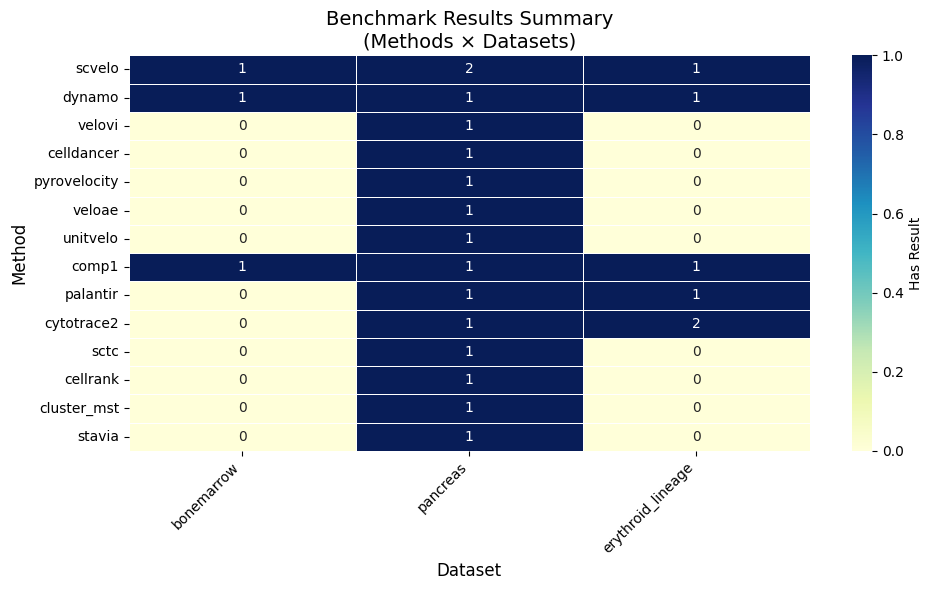

<Figure size 640x480 with 0 Axes>

In [5]:
# 可视化热力图
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(figsize=(10, max(6, len(pivot_table) * 0.4)))

# 创建数值矩阵用于热力图
heatmap_data = pivot_table.reindex(columns=[d for d in dataset_name_list if d in pivot_table.columns])

sns.heatmap(
    heatmap_data > 0, 
    annot=heatmap_data.values,  # 显示实际数量
    fmt="d",
    cmap="YlGnBu",
    cbar_kws={"label": "Has Result"},
    linewidths=0.5,
    ax=ax
)

ax.set_title("Benchmark Results Summary\n(Methods × Datasets)", fontsize=14)
ax.set_xlabel("Dataset", fontsize=12)
ax.set_ylabel("Method", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()
plt.savefig(f"{img_dir}/benchmark_summary_heatmap.png", dpi=300)

In [6]:
# 按 backend 分组统计
backend_summary = df_trajectories.groupby(["backend", "method"]).size().reset_index(name="count")
backend_pivot = backend_summary.pivot(index="method", columns="backend", values="count").fillna(0).astype(int)
print("各方法的后端分布:")
backend_pivot

各方法的后端分布:


backend,conda,local
method,,
celldancer,0,1
cellrank,0,1
cluster_mst,0,1
comp1,0,3
cytotrace2,1,2
dynamo,1,2
palantir,1,1
pyrovelocity,0,1
sctc,0,1


In [7]:
# 详细列表：按数据集分组显示所有方法
for dataset in dataset_name_list:
    subset = df_trajectories[df_trajectories["dataset"] == dataset]
    if len(subset) > 0:
        print(f"\n{'='*50}")
        print(f"📊 {dataset.upper()} ({len(subset)} methods)")
        print(f"{'='*50}")
        for _, row in subset.iterrows():
            print(f"  • {row['method']} ({row['backend']})")


📊 BONEMARROW (3 methods)
  • comp1 (local)
  • scvelo (local)
  • dynamo (local)

📊 PANCREAS (15 methods)
  • comp1 (local)
  • scvelo (local)
  • celldancer (local)
  • stavia (local)
  • cytotrace2 (local)
  • unitvelo (local)
  • sctc (local)
  • veloae (local)
  • palantir (local)
  • pyrovelocity (local)
  • dynamo (local)
  • scvelo (conda)
  • cluster_mst (local)
  • velovi (local)
  • cellrank (local)

📊 ERYTHROID_LINEAGE (6 methods)
  • comp1 (local)
  • palantir (conda)
  • dynamo (conda)
  • cytotrace2 (local)
  • scvelo (conda)
  • cytotrace2 (conda)


In [8]:
# 导出为 CSV (可选)
output_csv = f"{output_dir}/benchmark_method_dataset_heatmap.csv"
pivot_table.to_csv(output_csv)
print(f"已导出汇总表到: {output_csv}")

已导出汇总表到: ./output/25.12.24-benchmark_summary/benchmark_method_dataset_heatmap.csv
